In [1]:
%run /home/mrixen/Case_studies/Clean_code/functions/functions.ipynb

In [7]:
resolutions = ["R02B06", "R02B07", "R02B08", "R02B08_no_conv", "R02B09", "R02B10"]

# Time window for mask collapse
t_start = np.datetime64("2020-06-10T00")
t_end   = np.datetime64("2020-06-11T00")

data_path = "/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble"

# -------------------------------
# Compute 2D masks for all ensembles per resolution
# -------------------------------
all_fraction = {}

for res in resolutions:
    file_pattern = os.path.join(data_path, f"trajectories_{res}_ens*_08_12_1d.nc")
    ensemble_files = sorted(glob.glob(file_pattern))
    
    mask_list = []
    print(f"Processing resolution {res} ({len(ensemble_files)} ensembles)...")
    
    for fn in ensemble_files:
        try:
            ds = xr.open_dataset(fn)
            ds_WCB = select_WCB_trajectories_pressure_end_June(ds)
            mask_da_ascent = compute_WCB_mask(ds_WCB, pmin=100, pmax=400)
            ds.close()
            
            # Collapse time window (True if ascent occurs at any time in window)
            mask_period = mask_da_ascent.sel(time_abs=slice(t_start, t_end))
            mask_2d = mask_period.any(dim="time_abs")
            
            mask_list.append(mask_2d)
        except Exception as e:
            print(f"Skipping {fn}: {e}")
            continue
    
    if len(mask_list) == 0:
        print(f"No valid ensembles for {res}, skipping...")
        continue
    
    # Stack and compute fraction per grid cell
    mask_stack = xr.concat(mask_list, dim="ensemble")
    fraction = mask_stack.mean(dim="ensemble") * 100
    all_fraction[res] = fraction
    print(f"Computed fraction for {res}")

Processing resolution R02B06 (50 ensembles)...
Skipping /highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B06_ens13_08_12_1d.nc: Cannot apply_along_axis when any iteration dimensions are 0
Skipping /highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B06_ens27_08_12_1d.nc: Cannot apply_along_axis when any iteration dimensions are 0
Skipping /highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B06_ens32_08_12_1d.nc: Cannot apply_along_axis when any iteration dimensions are 0
Skipping /highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B06_ens41_08_12_1d.nc: Cannot apply_along_axis when any iteration dimensions are 0
Skipping /highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B06_ens44_08_12_1d.nc: Cannot apply_along_axis when any iteration dimensions are 0
Skipping /highres_nobackup/mrixen/simulations/June/Lagrant

In [8]:
#Same fbut for ERA5
# Open ERA5 dataset
ds_era = xr.open_dataset('/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/trajectories_ERA5_08_12_1d.nc')

# Select WCB trajectories
ds_era_WCB = select_WCB_trajectories_pressure_end_June(ds_era)

# Compute 2D mask (100–400 hPa)
mask_da_ascent_era = compute_WCB_mask(ds_era_WCB, pmin=100, pmax=400)

# Select time window: 10–11 June
t_start = np.datetime64("2020-06-10T00")
t_end   = np.datetime64("2020-06-12T00")
mask_period = mask_da_ascent_era.sel(time_abs=slice(t_start, t_end))

# Collapse over time → 2D mask
mask_2d = mask_period.any(dim="time_abs")  # True where ascent occurs in this window

# Optional: convert boolean to int for plotting
mask_plot = mask_2d.astype(int) * 100  # 0 = no ascent, 100 = ascent

# Convert to float
mask_float = mask_2d.astype(float)

# Apply spatial smoothing (adjust sigma if needed)
mask_smooth = xr.DataArray(
    gaussian_filter(mask_float, sigma=1.2),
    coords=mask_float.coords,
    dims=mask_float.dims
)

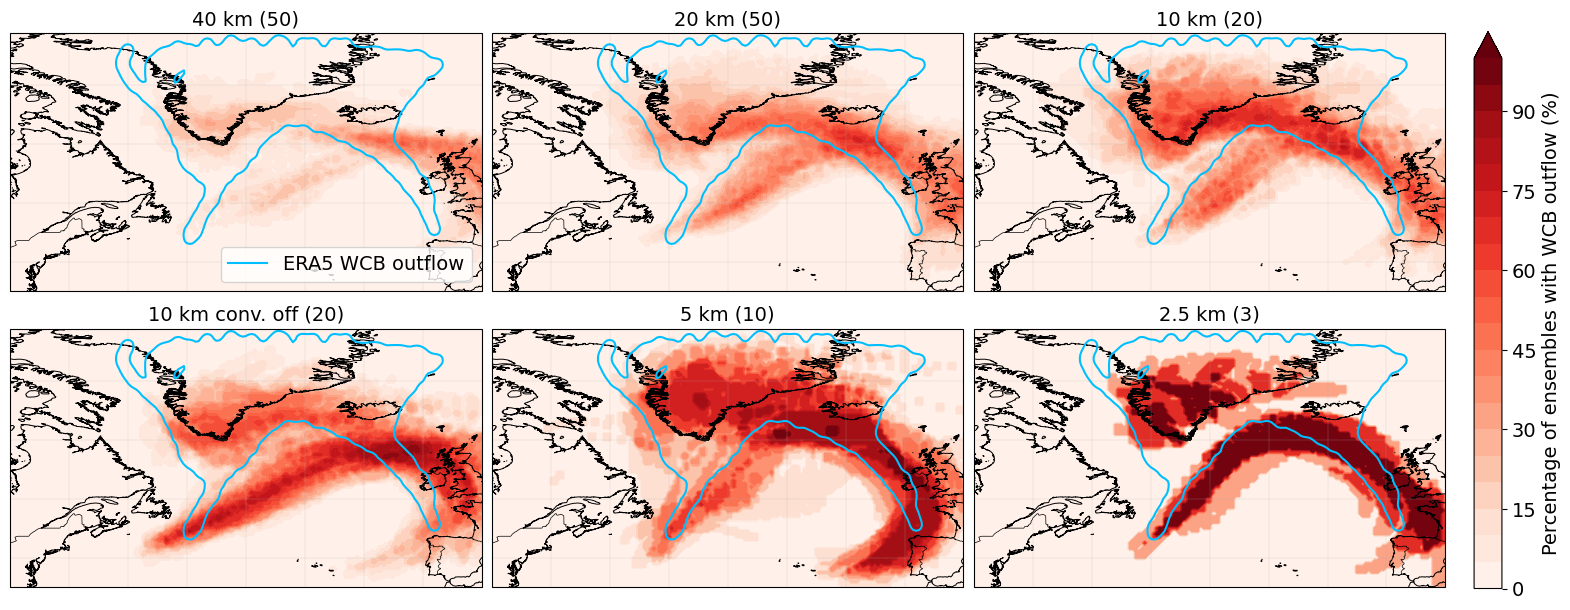

In [14]:
labels = {
    "R02B06": "40 km",
    "R02B07": "20 km",
    "R02B08": "10 km",
    "R02B08_no_conv": "10 km conv. off",
    "R02B09": "5 km",
    "R02B10": "2.5 km"
}
n_ens = {
    "R02B06": 50,
    "R02B07": 50,
    "R02B08": 20,
    "R02B08_no_conv": 20,
    "R02B09": 10,
    "R02B10": 3
}
n_res = len(all_fraction)
n_cols = 3
n_rows = int(np.ceil(n_res / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5.2 * n_cols, 3 * n_rows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

for i, (res, fraction) in enumerate(all_fraction.items()):
    ax = axes[i]
    ax.set_extent([-80, 0, 35, 76])
    ax.coastlines(resolution="10m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    #ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)


    cf = ax.contourf(
        fraction.lon,
        fraction.lat,
        fraction,
        levels=np.linspace(0, 100, 21),
        cmap="Reds",
        extend="max",
        transform=ccrs.PlateCarree()
    )

    cs = ax.contour(
        mask_smooth.lon,
        mask_smooth.lat,
        mask_smooth,
        levels=[0.3],   # threshold after smoothing (tune 0.2–0.5)
        colors="deepskyblue",
        linewidths=1.5,
        transform=ccrs.PlateCarree(),
        label="ERA5 WCB outflow"
    )
    
    ens_count = n_ens.get(res, "?")
    ax.set_title(f"{labels.get(res, res)} ({ens_count})")


era_handle = Line2D(
    [], [], 
    color="deepskyblue",
    linewidth=1.5,
    label="ERA5 WCB outflow"
)

axes[0].legend(handles=[era_handle], loc="lower right", frameon=True)

# Turn off unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Shared colorbar
cbar = fig.colorbar(cf, ax=axes[:n_res], orientation="vertical", pad=0.02, shrink=0.99)
cbar.set_label("Percentage of ensembles with WCB outflow (%)")

#fig.suptitle("WCB ascent probability (100–400 hPa) 10–11 June 2020", fontsize=14)
plt.savefig("../Figures/June_WCB_outflow.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Ascent velocity

In [24]:
resolutions = ["R02B07", "R02B08", "R02B08_no_conv", "R02B09", "R02B10"]
labels = ["20km", "10km", "10km conv. off", "5km", "2.5km"]

# Store 99.5th percentile "ascent rate" for each ensemble per resolution
p_rate_99 = {res: {} for res in resolutions}

for res in resolutions:
    file_pattern = (
        f"/highres_nobackup/mrixen/simulations/June/Lagranto_all/"
        f"output/ensemble/trajectories_{res}_ens*_08_12_1d.nc"
    )
    ensemble_files = sorted(glob.glob(file_pattern))

    for fn in ensemble_files:
        print(fn)
        ds = xr.open_dataset(fn)
        ds_WCB = select_WCB_trajectories_pressure_end_point(ds)

        # Compute pressure change per hour: Δp / Δt
        # pressure in hPa, time in hours
        pressure = ds_WCB["pressure"]  # shape: (trajectory, time)
        time_diff = np.diff(ds_WCB["time"].values) #/ np.timedelta64(1, "s")  # in seconds
        #time_diff = time_diff / 3600.0  # convert seconds → hours

        # Δp along time axis
        dp = np.diff(pressure, axis=1)
        # Divide by Δt to get hPa/h
        p_rate = -dp / time_diff  # negative because decreasing pressure = ascent

        # Flatten to 1D across trajectories and time
        p_rate_all = p_rate.ravel()
        p_rate_all = p_rate_all[np.isfinite(p_rate_all)]

        if len(p_rate_all) == 0:
            p_rate_99_val = np.nan
        else:
            p_rate_99_val = np.quantile(p_rate_all, 0.95)  # 99th percentile

        p_rate_99[res][fn] = p_rate_99_val
        ds.close()

/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B07_ens01_08_12_1d.nc
/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B07_ens02_08_12_1d.nc
/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B07_ens03_08_12_1d.nc
/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B07_ens04_08_12_1d.nc
/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B07_ens05_08_12_1d.nc
/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B07_ens06_08_12_1d.nc
/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B07_ens07_08_12_1d.nc
/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B07_ens08_08_12_1d.nc
/highres_nobackup/mrixen/simulations/June/Lagranto_all/output/ensemble/trajectories_R02B07_ens09_08_12_1d.nc
/highres_nobackup/m

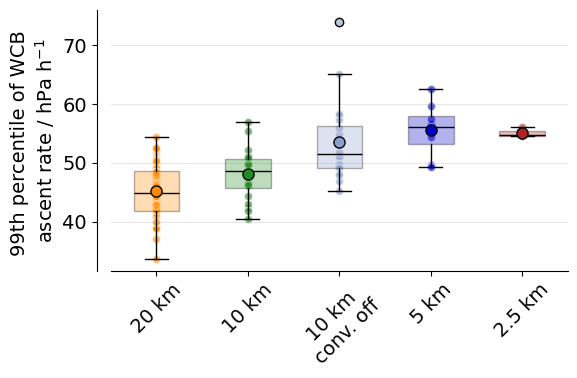

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define colors and labels ---
colors = {
    "R02B07": "darkorange",
    "R02B08": "forestgreen",
    "R02B08_no_conv": "#8da0cb",
    "R02B09": "mediumblue",
    "R02B10": "firebrick",
}

resolutions = ["R02B07", "R02B08", "R02B08_no_conv", "R02B09", "R02B10"]
labels = ["20 km", "10 km", "10 km\nconv. off", "5 km", "2.5 km"]
x_positions = np.arange(len(resolutions))

# --- Collect 99th percentile ascent velocity per ensemble ---
data = []
for res in resolutions:
    vals = [v for v in p_rate_99[res].values() if np.isfinite(v)]
    data.append(vals)

# --- Create figure ---
fig, ax = plt.subplots(figsize=(6, 4))

# --- Scatter individual ensembles ---
for i, vals in enumerate(data):
    ax.scatter(
        [x_positions[i]] * len(vals),
        vals,
        color=colors[resolutions[i]],
        alpha=0.6,
        zorder=1,
        edgecolor='white',
    )

# --- Boxplot ---
bp = ax.boxplot(
    data,
    positions=x_positions,
    widths=0.5,
    patch_artist=True,
    showmeans=True,
    medianprops=dict(color="black"),
    meanprops=dict(marker="o", markersize=8, markeredgewidth=1.5),
)

# --- Style boxes and mean markers ---
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[resolutions[i]])
    patch.set_alpha(0.3)

    mean_marker = bp['means'][i]
    mean_marker.set_markerfacecolor(colors[resolutions[i]])
    mean_marker.set_markeredgecolor('black')
    mean_marker.set_markeredgewidth(1)
    mean_marker.set_markersize(8)

# --- Axes formatting ---
ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("99th percentile of WCB \nascent rate / hPa h$^{-1}$")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_position(("outward", 10))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../Figures/June_WCB_ascent_velocity.pdf", dpi=300, bbox_inches="tight")
plt.show()